<a href="https://colab.research.google.com/github/eternitvy/ML_26/blob/main/JS04/JS04_TUGAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
# 1. LOAD DATASET & DEDIKASI VARIABEL
df = pd.read_csv('insurance.csv')

# Pemisahan Fitur (X) dan Target (y)
X = df.drop(columns=['charges'])
y = df['charges']

numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

In [3]:
# 2. PEMBAGIAN DATA (TRAIN & TEST SPLIT)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [4]:
# 3. FEATURE SCALING & PREPROCESSING
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

In [5]:
# 4 & 5. MODEL MULTIPLE LINEAR REGRESSION
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Melatih model Regresi Linear
lr_pipeline.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_lr = lr_pipeline.predict(X_test)

In [6]:
# 6. EVALUASI MODEL REGRESI LINEAR
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=== EVALUASI MULTIPLE LINEAR REGRESSION ===")
print(f"R-squared (R2) : {r2_lr:.4f}")
print(f"Mean Squared Error (MSE) : {mse_lr:.2f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}\n")

=== EVALUASI MULTIPLE LINEAR REGRESSION ===
R-squared (R2) : 0.7836
Mean Squared Error (MSE) : 33596915.85
Mean Absolute Error (MAE): 4181.19



In [7]:
# 7. MODEL SVR DENGAN HYPERPARAMETER TUNING
svr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR())
])

# Grid Search untuk menentukan kombinasi hyperparameter terbaik
param_grid = {
    'regressor__C': [1000, 5000, 10000, 20000],
    'regressor__gamma': ['scale', 'auto', 0.01, 0.1],
    'regressor__kernel': ['rbf']
}

grid_svr = GridSearchCV(svr_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train, y_train)

# Prediksi menggunakan model SVR terbaik
best_svr_model = grid_svr.best_estimator_
y_pred_svr = best_svr_model.predict(X_test)

# Evaluasi SVR
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("=== EVALUASI SUPPORT VECTOR REGRESSOR (SVR) ===")
print(f"Parameter Terbaik: {grid_svr.best_params_}")
print(f"R-squared (R2) : {r2_svr:.4f}")
print(f"Mean Squared Error (MSE) : {mse_svr:.2f}")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}\n")

=== EVALUASI SUPPORT VECTOR REGRESSOR (SVR) ===
Parameter Terbaik: {'regressor__C': 20000, 'regressor__gamma': 'auto', 'regressor__kernel': 'rbf'}
R-squared (R2) : 0.8526
Mean Squared Error (MSE) : 22890686.88
Mean Absolute Error (MAE): 1786.80



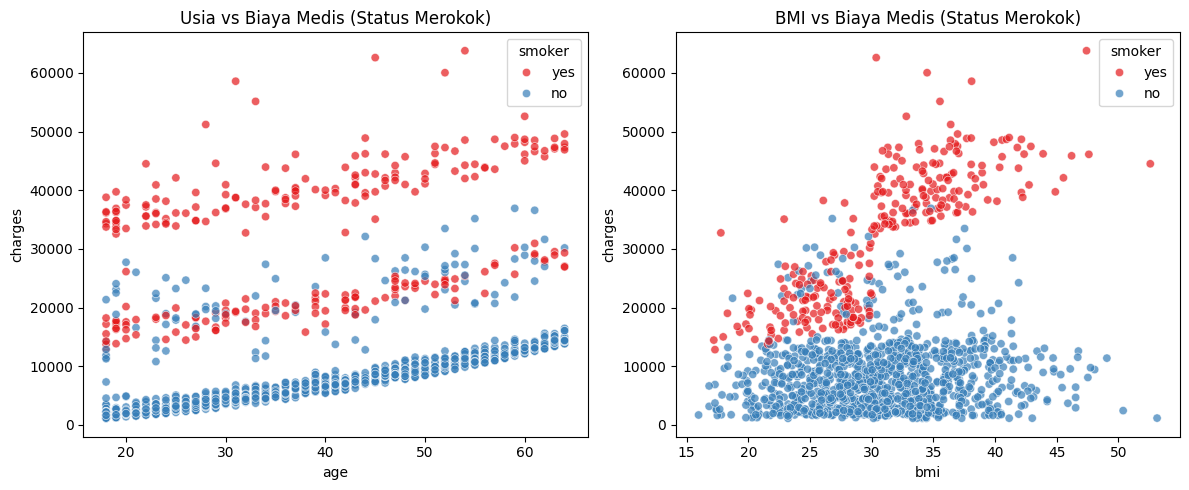

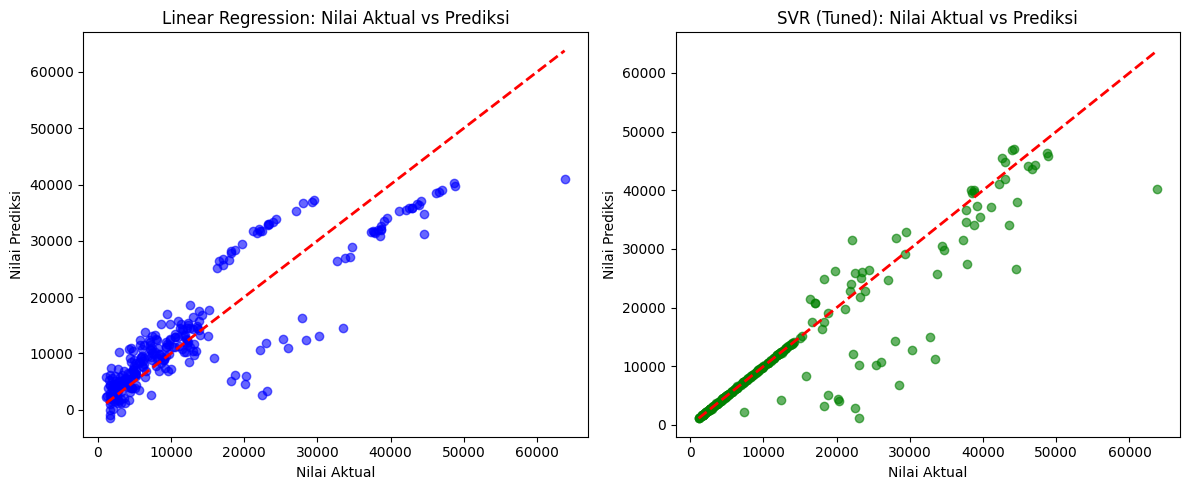

In [8]:
# VISUALISASI DATA & HASIL MODEL
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('Usia vs Biaya Medis (Status Merokok)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('BMI vs Biaya Medis (Status Merokok)')
plt.tight_layout()
plt.show()

# Grafik Perbandingan Prediksi vs Aktual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Nilai Aktual vs Prediksi')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_svr, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('SVR (Tuned): Nilai Aktual vs Prediksi')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')

plt.tight_layout()
plt.show()